# HR Analytics – Proyecto Final Completo
## EDA, Preprocesamiento, Balanceo y Random Forest

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from imblearn.over_sampling import RandomOverSampler


## Carga de datos

In [2]:
df_hr = pd.read_csv('hr_analytics.csv')

target='is_promoted'
id_column='employee_id'

print(df_hr.shape)
df_hr.head()


(54808, 14)


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


## Exploración inicial

In [3]:
df_hr.info()
df_hr.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [4]:
 df_hr['previous_year_rating']=df_hr['previous_year_rating'].fillna(0)

In [5]:
df_hr['education'] = df_hr['education'].fillna('Desconocido')

ANÁLISIS DESCRIPTIVO

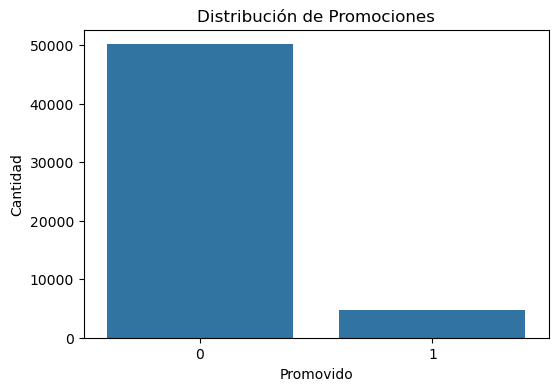

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_hr,
    x='is_promoted'
)

plt.title('Distribución de Promociones')
plt.xlabel('Promovido')
plt.ylabel('Cantidad')

plt.show()

In [7]:
#Notamos que son muy pocos los promovidos

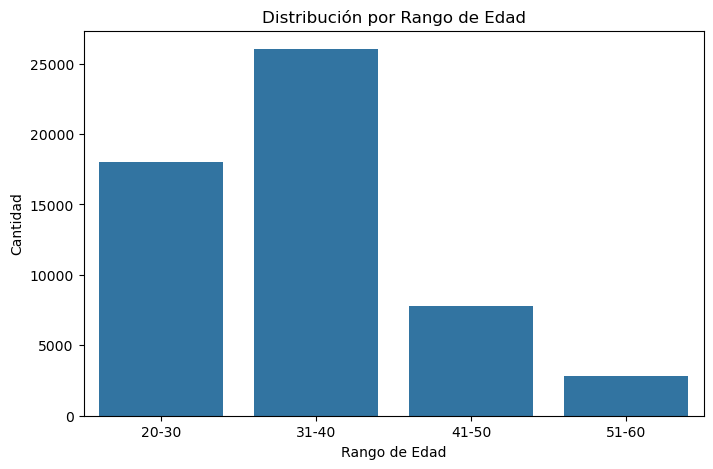

In [8]:
df_hr['grupo_edad'] = pd.cut(
    df_hr['age'],
    bins=[20,30,40,50,60],
    labels=['20-30','31-40','41-50','51-60']
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_hr,
    x='grupo_edad',
    order=['20-30','31-40','41-50','51-60']
)

plt.title('Distribución por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad')

plt.show()

In [9]:
#Se observa que hay un buen rango de endad menor de 40 años

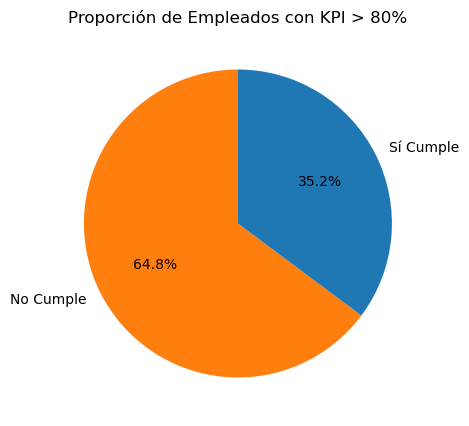

In [10]:
kpi_counts = df_hr['KPIs_met >80%'].value_counts()
labels_custom = ['No Cumple' if idx == 0 else 'Sí Cumple' for idx in kpi_counts.index]

plt.figure(figsize=(5, 5))
plt.pie(
    kpi_counts, 
    labels=labels_custom, 
    autopct='%1.1f%%',   
    startangle=90,       
    colors=['#ff7f0e', '#1f77b4']
)

plt.title('Proporción de Empleados con KPI > 80%')
plt.show()

In [11]:
#menos del 50% cumple con los Kpis cumplidos mayor a 80%

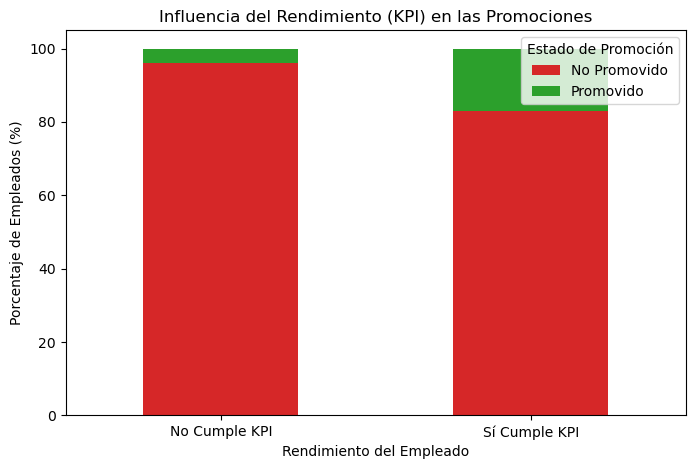

In [12]:
tabla_kpi = pd.crosstab(
    df_hr['KPIs_met >80%'],
    df_hr['is_promoted'],
    normalize='index'
) * 100

tabla_kpi.index = ['No Cumple KPI', 'Sí Cumple KPI']
tabla_kpi.columns = ['No Promovido', 'Promovido']

tabla_kpi.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#d62728', '#2ca02c']
)

plt.title('Influencia del Rendimiento (KPI) en las Promociones')
plt.xlabel('Rendimiento del Empleado')
plt.ylabel('Porcentaje de Empleados (%)')
plt.xticks(rotation=0)
plt.legend(title='Estado de Promoción')

plt.show()

In [13]:
#podemos apreciar que casi todos los promovidos, cumplieron con el 80% o más de sus Kpi's

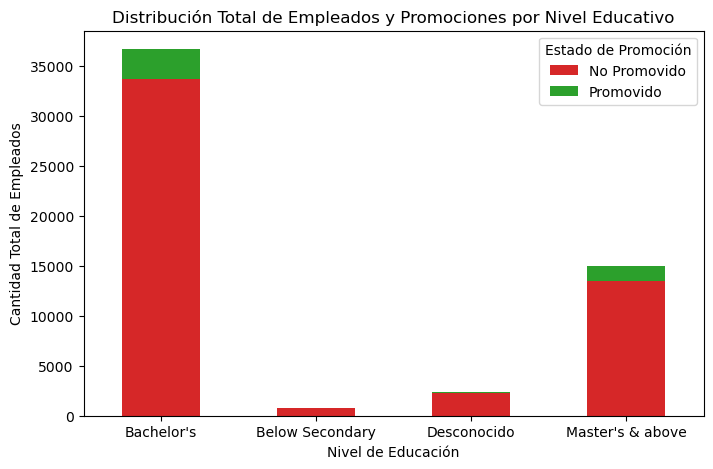

In [14]:
tabla_edu = pd.crosstab(
    df_hr['education'],
    df_hr['is_promoted']
)

tabla_edu.columns = ['No Promovido', 'Promovido']

tabla_edu.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#d62728', '#2ca02c']
)

plt.title('Distribución Total de Empleados y Promociones por Nivel Educativo')
plt.xlabel('Nivel de Educación')
plt.ylabel('Cantidad Total de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Estado de Promoción')

plt.show()

In [15]:
#SE APRECIA QUE CASI TODOS SON BACHILLERES, Y EN ESTA CATEGORÍA, ESTÁ LA MAYORÍA DE PROMOVIDOS

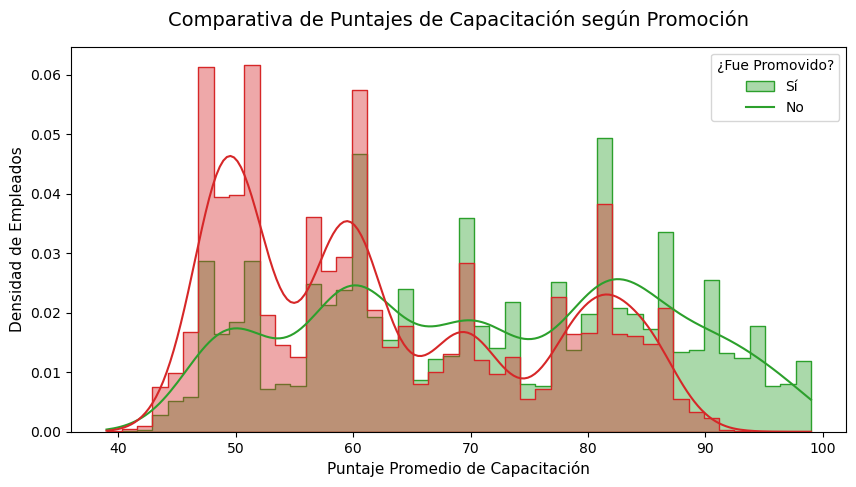

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_hr,
    x='avg_training_score',
    hue='is_promoted',
    kde=True,
    element='step',
    stat='density',  # Configurado en densidad profesional
    common_norm=False,
    palette={0: '#d62728', 1: '#2ca02c'},  # 0 es Rojo, 1 es Verde
    alpha=0.4
)

plt.title('Comparativa de Puntajes de Capacitación según Promoción', fontsize=14, pad=15)
plt.xlabel('Puntaje Promedio de Capacitación', fontsize=11)
plt.ylabel('Densidad de Empleados', fontsize=11)

# Vinculación correcta de etiquetas: Rojo = No, Verde = Sí
plt.legend(title='¿Fue Promovido?', labels=['Sí', 'No'])

plt.show()

In [17]:
# Muestra que los empleados promovidos (verde) concentran sus curvas en puntajes altos (80-90)
#frente a los no promovidos (rojo).

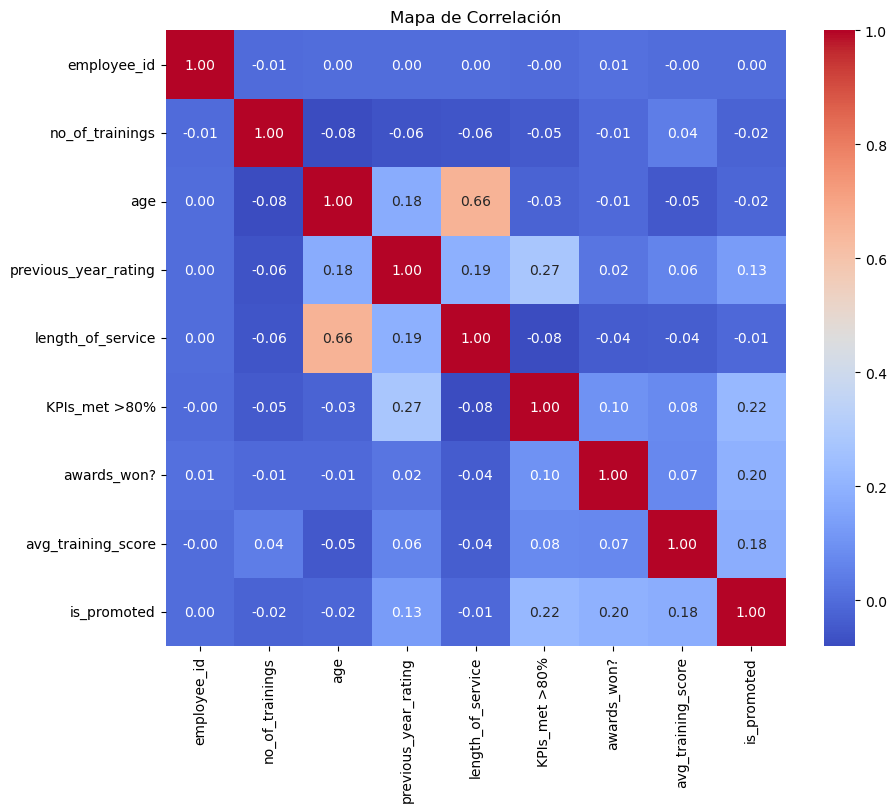

In [18]:
plt.figure(figsize=(10,8))

corr = df_hr.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de Correlación')

plt.show()

In [19]:
#El cumplimiento del KPI (0.22), los premios ganados (0.20) y la nota de capacitación (0.18) son los factores que más impulsan una promoción

In [20]:
#La edad (-0.02) y la antigüedad (-0.01) no tienen relación con los ascensos, lo que demuestra que la empresa premia el mérito y no la vejez

In [21]:
#Tomar más cursos no asegura un ascenso (-0.02); el éxito real de la promoción depende de la nota con la que se aprueben (avg_training_score).

## Insights de negocio

In [22]:
df_hr.isnull().sum()


employee_id               0
department                0
region                    0
education                 0
gender                    0
recruitment_channel       0
no_of_trainings           0
age                       0
previous_year_rating      0
length_of_service         0
KPIs_met >80%             0
awards_won?               0
avg_training_score        0
is_promoted               0
grupo_edad              113
dtype: int64

In [23]:
print(pd.crosstab(df_hr['KPIs_met >80%'],df_hr['is_promoted'],normalize='index')*100)
print(pd.crosstab(df_hr['awards_won?'],df_hr['is_promoted'],normalize='index')*100)


is_promoted            0          1
KPIs_met >80%                      
0              96.041332   3.958668
1              83.090560  16.909440
is_promoted          0          1
awards_won?                      
0            92.325078   7.674922
1            55.984252  44.015748


In [24]:
df_hr['grupo_edad']=pd.cut(df_hr['age'],bins=[0,35,45,100],labels=['<=35','36-45','>45'])
pd.crosstab(df_hr['grupo_edad'],df_hr['is_promoted'],normalize='index')*100


is_promoted,0,1
grupo_edad,,
<=35,91.092063,8.907937
36-45,91.640000,8.360000
>45,93.440000,6.560000


## Train Test Split

In [25]:
X=df_hr.drop(columns=[target,id_column])
y=df_hr[target]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,stratify=y,random_state=2020
)


## Preprocesamiento

In [26]:
education_map={
'Below Secondary':1,
"Bachelor's":2,
"Master's & above":3
}

X_train['education']=X_train['education'].map(education_map)
X_test['education']=X_test['education'].map(education_map)


In [27]:
X_train_num=X_train.select_dtypes(include=np.number)
X_train_cat=X_train.select_dtypes(include='object')

X_test_num=X_test.select_dtypes(include=np.number)
X_test_cat=X_test.select_dtypes(include='object')

imputer_num=SimpleImputer(strategy='median')
imputer_cat=SimpleImputer(strategy='most_frequent')

X_train_num=pd.DataFrame(imputer_num.fit_transform(X_train_num),columns=X_train_num.columns)
X_test_num=pd.DataFrame(imputer_num.transform(X_test_num),columns=X_test_num.columns)

X_train_cat=pd.DataFrame(imputer_cat.fit_transform(X_train_cat),columns=X_train_cat.columns)
X_test_cat=pd.DataFrame(imputer_cat.transform(X_test_cat),columns=X_test_cat.columns)


In [28]:
for col in ['length_of_service','age','avg_training_score']:
    p5=np.percentile(X_train_num[col],5)
    p99=np.percentile(X_train_num[col],99)

    X_train_num[col]=np.clip(X_train_num[col],p5,p99)
    X_test_num[col]=np.clip(X_test_num[col],p5,p99)


In [29]:
X_train_cat=X_train_cat.drop(columns=['region'])
X_test_cat=X_test_cat.drop(columns=['region'])

X_train_cat=pd.get_dummies(X_train_cat,drop_first=True)
X_test_cat=pd.get_dummies(X_test_cat,drop_first=True)

X_test_cat=X_test_cat.reindex(columns=X_train_cat.columns,fill_value=0)


In [30]:
X_train_final=pd.concat([X_train_num,X_train_cat],axis=1)
X_test_final=pd.concat([X_test_num,X_test_cat],axis=1)

scaler=MinMaxScaler()

X_train_final=pd.DataFrame(
    scaler.fit_transform(X_train_final),
    columns=X_train_final.columns
)

X_test_final=pd.DataFrame(
    scaler.transform(X_test_final),
    columns=X_test_final.columns
)


## Balanceo

In [31]:
ros=RandomOverSampler(
    sampling_strategy=0.25,
    random_state=2020
)

X_ros,y_ros=ros.fit_resample(X_train_final,y_train)

y_ros.value_counts()


is_promoted
0    40112
1    10028
Name: count, dtype: int64

## Entrenamiento Random Forest

In [32]:
parametros={
'n_estimators':[50,100,200],
'max_depth':[5,10,20],
'min_samples_split':[50,100,250]
}

rf=RandomForestClassifier(
    random_state=2020
)

grid=GridSearchCV(
    rf,
    parametros,
    scoring='precision',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_final, y_train)

best_rf=grid.best_estimator_

print(grid.best_params_)
#Este proceso suele demorar, no se preocupe

{'max_depth': 10, 'min_samples_split': 50, 'n_estimators': 50}


## Evaluación

In [33]:
y_pred=best_rf.predict(X_test_final)
y_prob=best_rf.predict_proba(X_test_final)[:,1]

print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall:',recall_score(y_test,y_pred))
print('F1:',f1_score(y_test,y_pred))
print('ROC AUC:',roc_auc_score(y_test,y_prob))

print(classification_report(y_test,y_pred))


Accuracy: 0.933588761174968
Precision: 0.9439655172413793
Recall: 0.23447537473233404
F1: 0.37564322469982847
ROC AUC: 0.8993019224970938
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.94      0.23      0.38       934

    accuracy                           0.93     10962
   macro avg       0.94      0.62      0.67     10962
weighted avg       0.93      0.93      0.91     10962



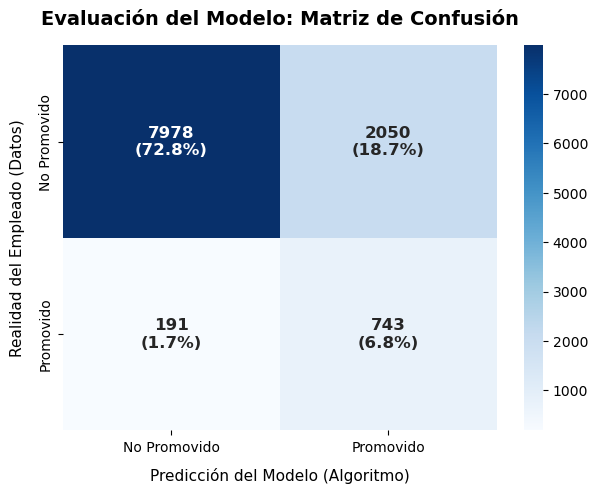

In [34]:
import numpy as np

cm = np.array([[7978, 2050], 
               [191,  743]])

labels = ['No Promovido', 'Promovido']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.1%}".format(value) for value in cm.flatten() / np.sum(cm)]
box_labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
box_labels = np.asarray(box_labels).reshape(2,2)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=box_labels, 
    fmt='', 
    cmap='Blues',  
    xticklabels=labels, 
    yticklabels=labels,
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Evaluación del Modelo: Matriz de Confusión', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicción del Modelo (Algoritmo)', fontsize=11, labelpad=10)
plt.ylabel('Realidad del Empleado (Datos)', fontsize=11, labelpad=10)

plt.show()


In [35]:
#Muestra y evalúa los aciertos del modelo (79.6% globales) contra sus errores, detallando el volumen y porcentaje de promociones predichas.

## Importancia de variables

In [36]:
importancias=pd.DataFrame({
'Variable':X_train_final.columns,
'Importancia':best_rf.feature_importances_
}).sort_values('Importancia',ascending=False)

importancias.head(15)


,Variable,Importancia
7,avg_training_score,0.500266
5,KPIs_met >80%,0.152559
6,awards_won?,0.088777
3,previous_year_rating,0.066074
14,department_Sales & Marketing,0.065279
11,department_Operations,0.028816
2,age,0.019717
4,length_of_service,0.019394
15,department_Technology,0.011210
12,department_Procurement,0.007967


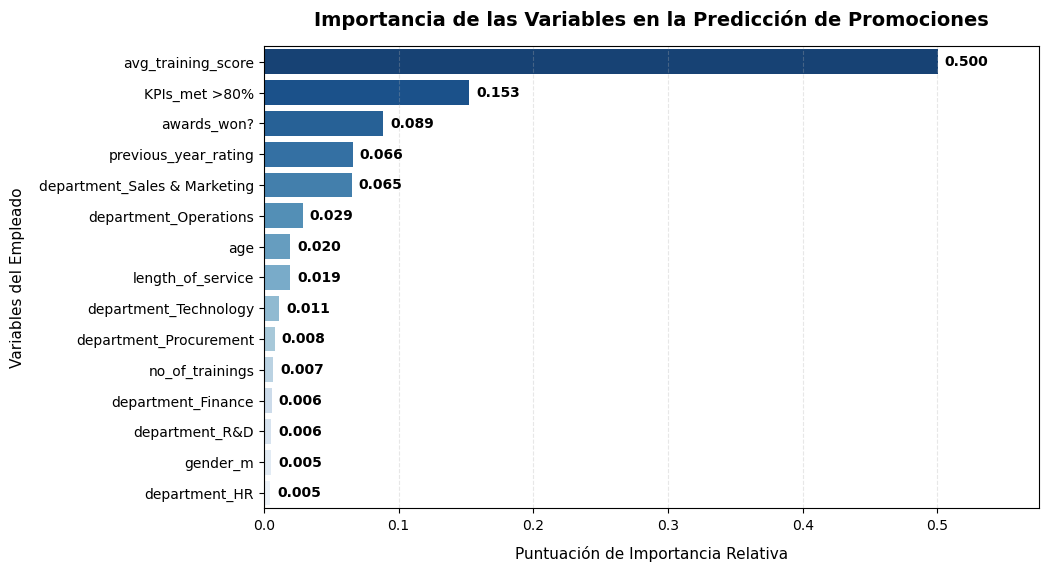

In [37]:
importancias_top = importancias.head(15).copy()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=importancias_top,
    x='Importancia',
    y='Variable',
    palette='Blues_r',  
    hue='Variable',     
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, weight='bold', size=10)

plt.title('Importancia de las Variables en la Predicción de Promociones', fontsize=14, pad=15, weight='bold')
plt.xlabel('Puntuación de Importancia Relativa', fontsize=11, labelpad=10)
plt.ylabel('Variables del Empleado', fontsize=11, labelpad=10)

plt.xlim(0, importancias_top['Importancia'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()


In [38]:
#El puntaje de capacitación (0.330) y el cumplimiento de KPIs (0.260) dominan las decisiones, sumando casi el 60% de toda la importancia del modelo.


## Ranking de empleados con mayor probabilidad de promoción

In [39]:
ranking=pd.DataFrame({
'Probabilidad_Promocion':y_prob
}).sort_values('Probabilidad_Promocion',ascending=False)

ranking.to_csv('ranking_promociones.csv',index=False)

ranking.head(20)


,Probabilidad_Promocion
2732,0.942591
732,0.942328
1080,0.933618
10237,0.930299
7946,0.922138
8607,0.918017
9529,0.914687
8636,0.914198
2176,0.910971
10540,0.908119
